# Fluid flow past a 2D cylinder: Visualizing results

In this notebook, we visualize the latent SDE fit by `train_cylinder.py` to the top $K = 38$ POD coefficients of the flow past a 2D cylinder.

## Imports

In [1]:
# Generic imports
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import flax.linen as nn

import numpy as np

import os
import pickle
from functools import partial

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
fontsize = 12

In [2]:
# Imports from helmholtz_sde
from helmholtz_sde.utils.plotting import plot_losses
from helmholtz_sde.sde import NeuralSDE, DriftNetwork
from helmholtz_sde.posterior.encoder import NullEncoder, constant_ctx
from helmholtz_sde.posterior.kernel_glm_posterior import GPInferenceNetwork, init_gp_posterior
from helmholtz_sde.posterior.drift import PosteriorSDE, simulate_posterior_samples

In [3]:
# Imports for the experiment and the shared experiment code
import sys
sys.path.append("..")
from experiment_utils import build_correction
from train_cylinder import constant_diagonal_diffusion
from cylinder_utils import add_colorbar, decode_velocity, plot_field, plot_pod_modes, plot_spacetime_correlation, simulate_frames, spacetime_correlation

In [4]:
# Auto-reload notebook
%load_ext autoreload
%autoreload 2

## Loading the checkpoint and the data

First, we load a model checkpoint written by the training script `train_cylinder.py`, together with the POD coefficients it was trained on.

In [ ]:
ckpt_path = None # NOTE: set to the path of a checkpoint written by train_cylinder.py
dataset_dir = "../datasets/cylinder"

In [6]:
with open(ckpt_path, "rb") as f:
    checkpoint = pickle.load(f)
params, metrics, cfg = checkpoint["params"], checkpoint["metrics"], checkpoint["config"]
K = cfg["K"]
div_free = build_correction(cfg["div_free"], cfg["ell"], cfg["kappa"], cfg["n_mc"]) # the correction used during training
print(f"Checkpoint {ckpt_path}: gauge {cfg['gauge']}, correction {div_free}, {cfg['n_iters']} iterations, final loss {metrics['loss'][-1]:.2f}")

# POD coefficients of the training and test frames (rescaled by z_scale), in model time starting at the first training frame
with open(os.path.join(dataset_dir, "encoded_data.pkl"), "rb") as f:
    blob = pickle.load(f)
z_train, z_test = np.array(blob["z_train"]), np.array(blob["z_test"]) # (T_train, K), (T_test, K)
t_offset = blob["t_train"][0] # physical time of the first training frame
t_train, t_test = np.array(blob["t_train"]) - t_offset, np.array(blob["t_test"]) - t_offset
dt_frame = t_train[1] - t_train[0]
z_scale, grid_shape, x_coord, y_coord = blob["z_scale"], blob["grid_shape"], blob["x_coord"], blob["y_coord"]
pca_components, pca_mean = blob["pca_components"], blob["pca_mean"]

# Noisy subsampled training observations, as in train_cylinder.py
z_obs, obs_times = z_train[::cfg["subsample_every"]], t_train[::cfg["subsample_every"]]
if cfg["obs_noise"] > 0:
    z_obs = z_obs + cfg["code_stdev"] * np.random.default_rng(42).standard_normal(z_obs.shape)
ys, obs_times = jnp.array(z_obs)[None], jnp.array(obs_times)[None] # (B, T, K), (B, T), a single trial
t_max = obs_times.max().item()
print(f"{ys.shape[1]} observations of {K} POD coefficients on [0, {t_max:.1f}] (physical time [{t_offset:.1f}, {t_offset + t_max:.1f}]), {len(t_test)} test frames after")

Checkpoint checkpoints/least_squares/sub3_noise0.3_fullcovTrue_gaugesqrt_h100_d2_ell1_k1_n1_key2.pkl: gauge sqrt, correction LeastSquaresCorrection(ell=1, jitter=1e-08, kappa=1, n_mc=1, n_nodes=None), 30000 iterations, final loss -25455.84
651 observations of 38 POD coefficients on [0, 195.0] (physical time [61.0, 256.0]), 488 test frames after


We rebuild the prior and posterior SDEs using the checkpoint; exactly as in `train_cylinder.py`.

In [ ]:
# Prior SDE and GP posterior, rebuilt as in train_cylinder.py
encoder, process_ctx = NullEncoder(value=0.), constant_ctx
gp_init = init_gp_posterior(cfg["n_tau"], K, (0.0, t_max), obs_times[0], ys[0], len_init=cfg["len_init"], full_cov=cfg["full_cov"]) # the lengthscale selected during training
post_net = GPInferenceNetwork(K=K, init_params=gp_init, full_cov=cfg["full_cov"])
drift_net = DriftNetwork(hidden_dim=cfg["hidden_size"], K=K, depth=cfg["depth"], activation=nn.tanh)
prior = NeuralSDE(K, apply_fn_drift=drift_net.apply, apply_fn_diffusion=constant_diagonal_diffusion)

# Posterior SDE of the single trial
params_trial = {**params, "posterior_params": jax.tree.map(lambda x: x[0], params["posterior_params"])}
ctx_seq, proc_ctx = encoder.apply(params["encoder_params"], ys[0]), partial(process_ctx, obs_times[0])
div_free_eval = build_correction(cfg["div_free"], cfg["ell"], cfg["kappa"], n_mc=64)
posterior_sde = PosteriorSDE(prior, post_net, ctx_seq, proc_ctx, gauge=cfg["gauge"], div_free=div_free_eval, key=jr.PRNGKey(5))

Finally, we plot the loss curves.

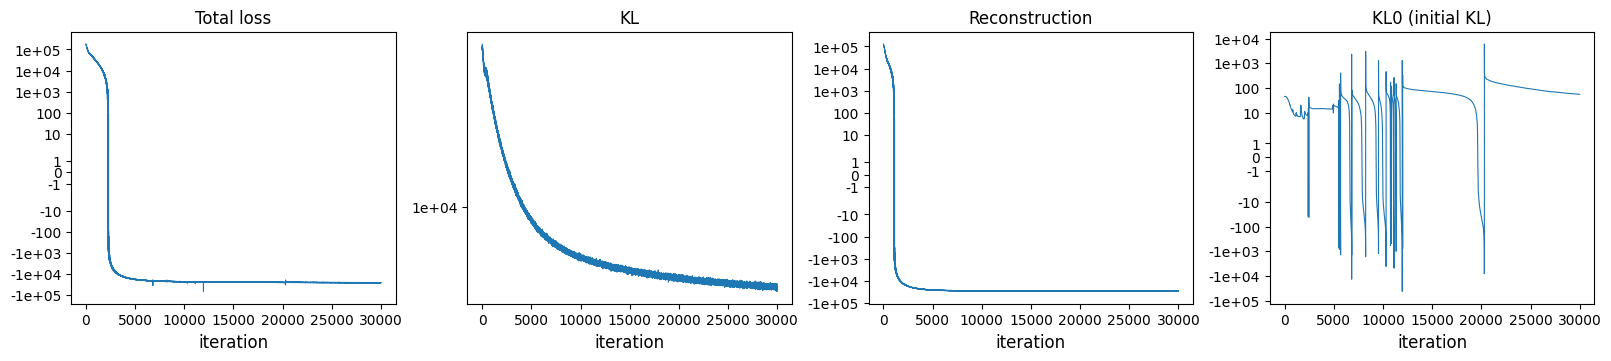

In [8]:
fig, axs = plot_losses(metrics, fontsize=fontsize)
plt.show()

## Visualizing the posterior

First, we visualize the learned posterior. We plot the posterior mean and $\pm 2$ standard deviations of the top $10$ POD coefficients over the first $20$ time units, against the true coefficients (grey).

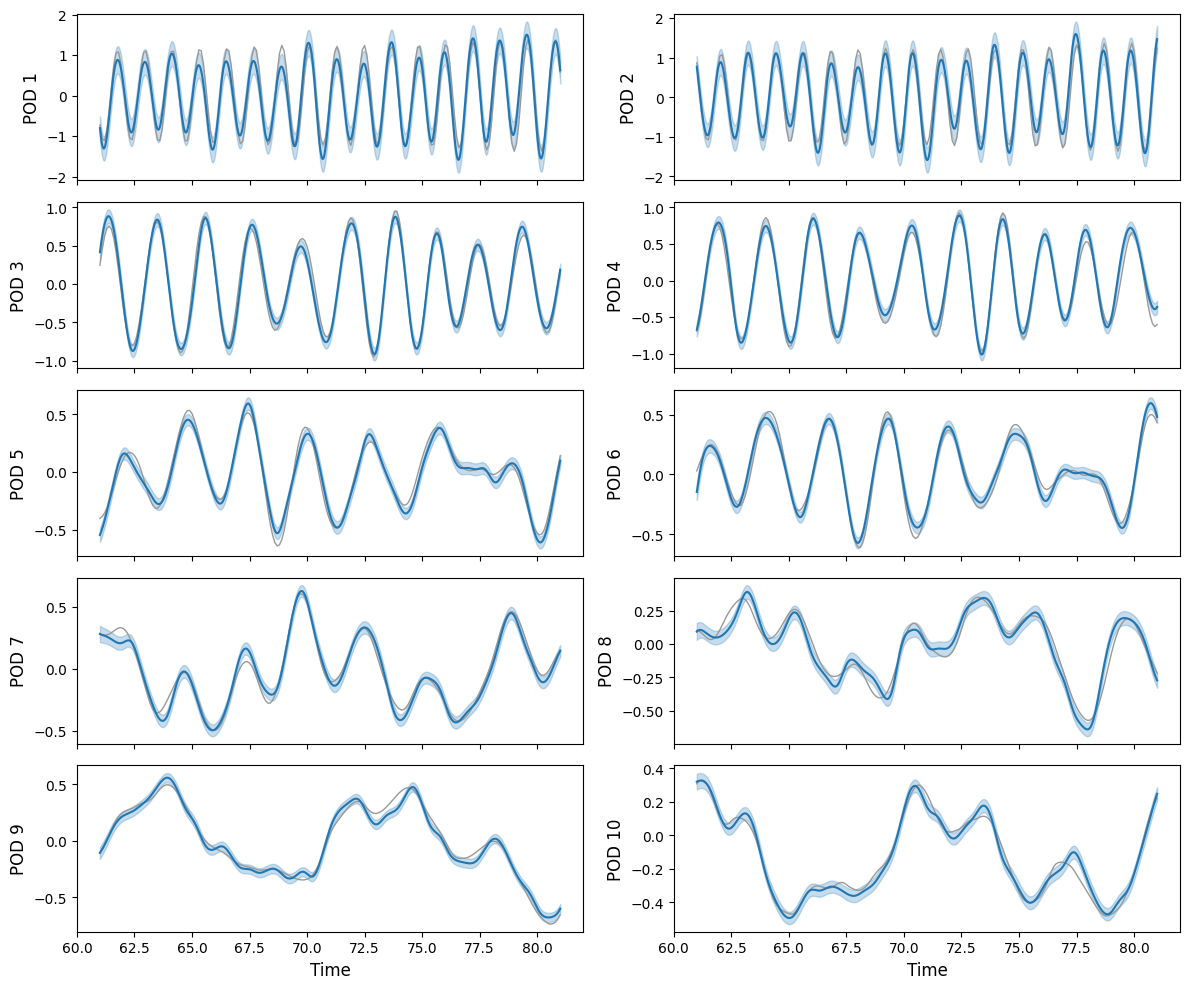

In [9]:
# Posterior mean and standard deviation on a grid over the first 20 time units
t_post = np.linspace(0.0, 20.0, 1001)
ms_post, Rs_post = vmap(lambda t: posterior_sde.marginal(t, params_trial))(jnp.array(t_post)) # (T_post, K), (T_post, K, K)
stds_post = np.sqrt(vmap(lambda R: jnp.diag(R @ R.T))(Rs_post))
mask_true = t_train <= t_post[-1]

fig, axs = plot_pod_modes(t_train[mask_true] + t_offset, z_train[mask_true], t_post + t_offset, mean=ms_post, band=(ms_post - 2 * stds_post, ms_post + 2 * stds_post), fontsize=fontsize)
plt.show()

We can also visualize draws from the approximate posterior SDE over the first $10$ time units, against the posterior mean (solid) and the true coefficients (grey).

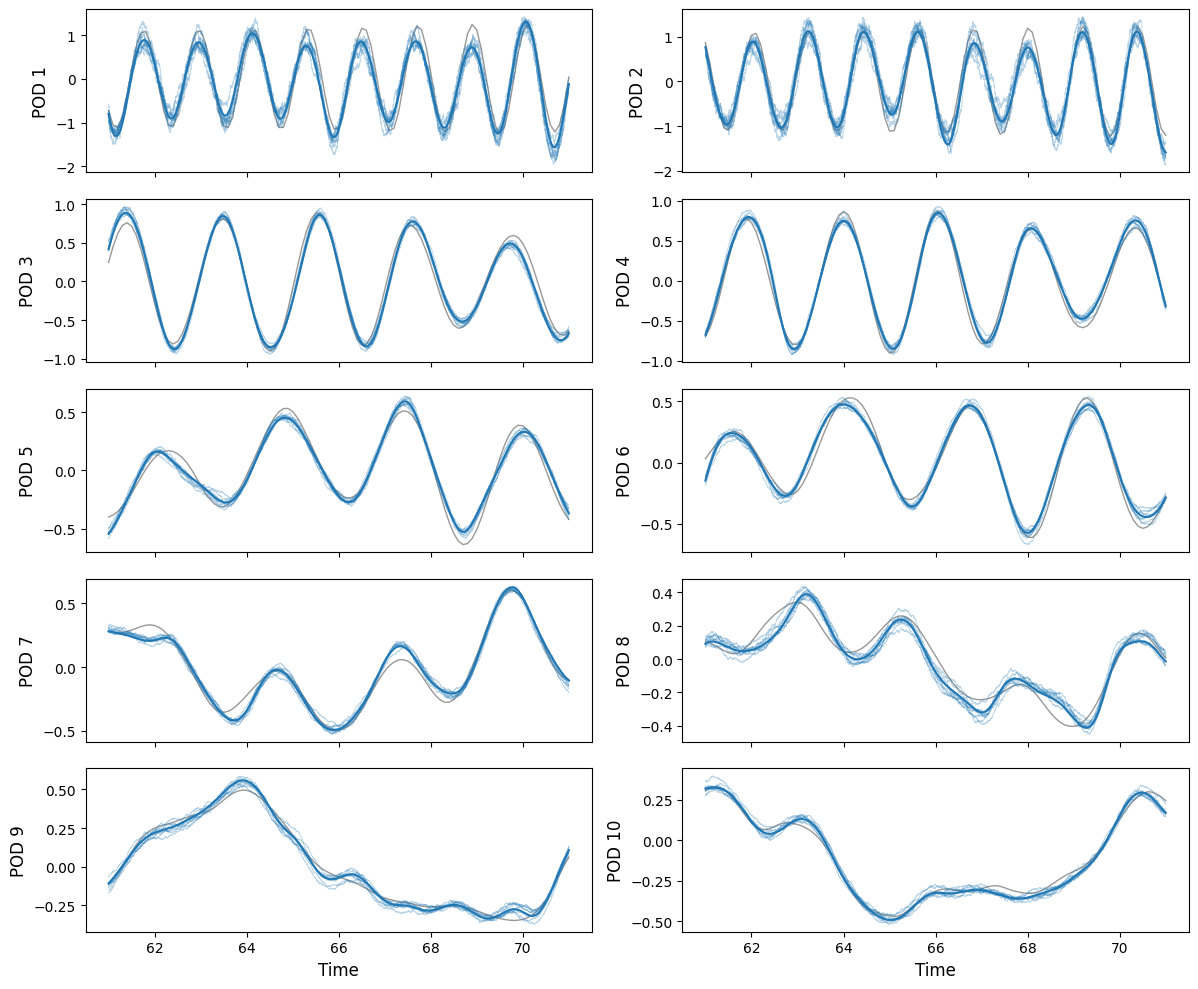

In [10]:
# Posterior sample paths over the first 10 time units
t_window = 10.0
n_post_samples = 8
xs_post = simulate_posterior_samples(jr.PRNGKey(7), posterior_sde, params_trial, t_max=t_window, n_timesteps=10_000, n_samples=n_post_samples) # (n_post_samples, n_timesteps + 1, K)
t_post_samples = np.linspace(0.0, t_window, xs_post.shape[1])
ms_window = vmap(lambda t: posterior_sde.marginal(t, params_trial)[0])(jnp.array(t_post_samples)) # posterior mean at the sample times
mask_true = t_train <= t_window

fig, axs = plot_pod_modes(t_train[mask_true] + t_offset, z_train[mask_true], t_post_samples + t_offset, mean=ms_window, samples=xs_post, fontsize=fontsize)
plt.show()

The posterior mean closely tracks the true POD modes, and the posterior standard deviation is well calibrated.

## Visualizing the prior

Next, we visualize the learned prior. We first visualize the learned diagonal diffusion coefficient.

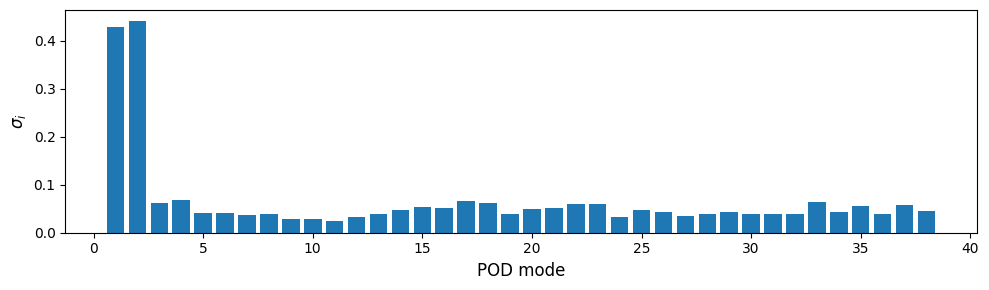

In [11]:
# Learned diffusion coefficient of each POD mode
sigma = jax.nn.softplus(params["sde_params"]["network_params_diffusion"])
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(np.arange(1, K + 1), np.array(sigma))
ax.set_xlabel("POD mode", fontsize=fontsize)
ax.set_ylabel(r"$\sigma_i$", fontsize=fontsize)
ax.tick_params(labelsize=fontsize - 2)
fig.tight_layout()
plt.show()

The top $2$ POD modes have the largest learned diffusion coefficients.

Next, we visualize draws from the prior over the first $10$ time units, starting from the (true) initial condition.

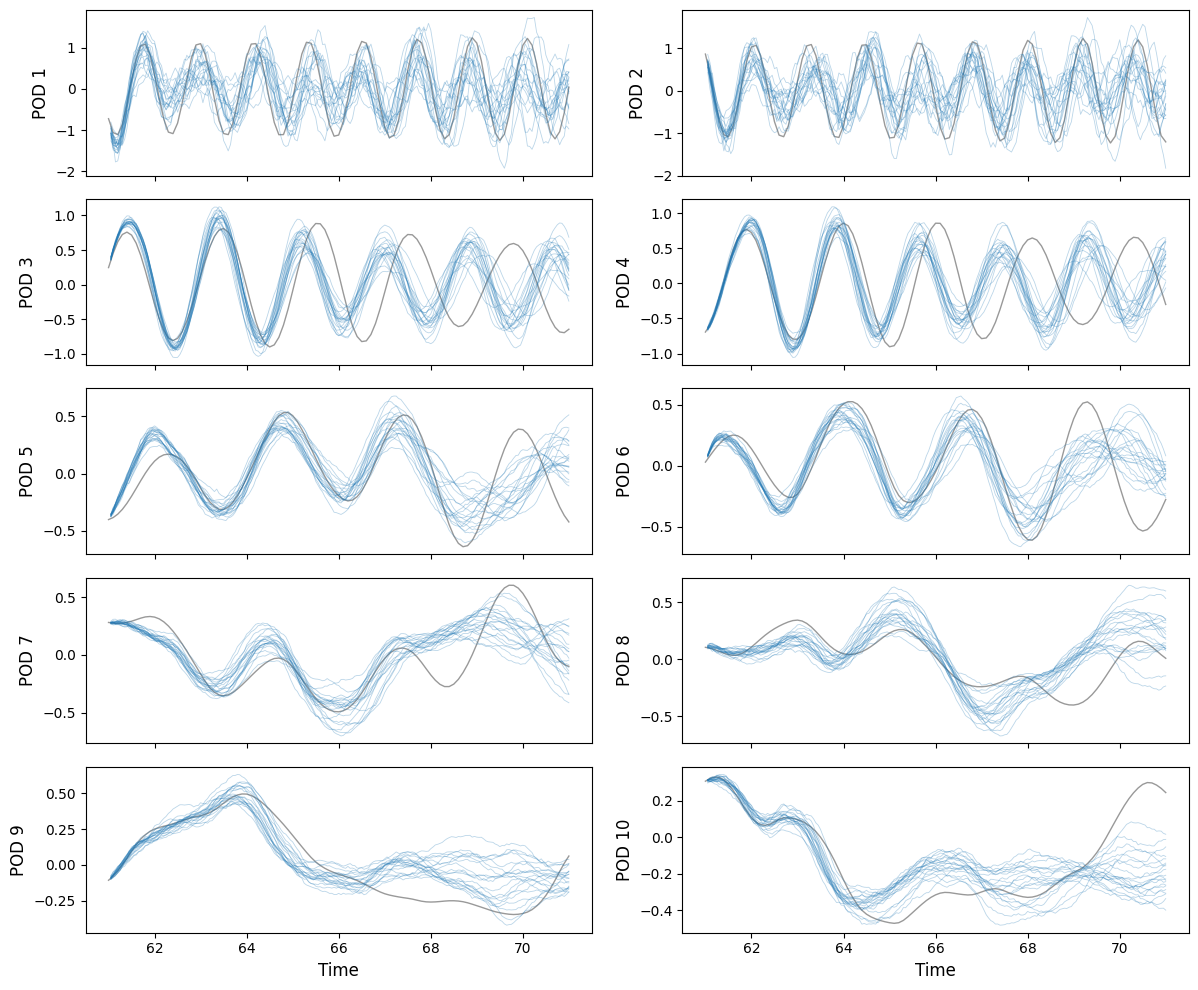

In [12]:
dt_sim = 1e-4
n_prior_samples = 512
dt_prior = 0.05
n_prior_frames = int(round(t_window / dt_prior))
x0 = jnp.array(z_train[0])
xs_prior = vmap(partial(simulate_frames, x0=x0, sde=prior, sde_params=params["sde_params"], dt_frame=dt_prior, n_frames=n_prior_frames, steps_per_frame=int(round(dt_prior / dt_sim))))(jr.split(jr.PRNGKey(42), n_prior_samples)) # (n_prior_samples, n_prior_frames, K)
t_prior = dt_prior * np.arange(1, n_prior_frames + 1)

fig, axs = plot_pod_modes(t_train[mask_true] + t_offset, z_train[mask_true], t_prior + t_offset, samples=xs_prior[:20], n_modes=10, fontsize=fontsize)
plt.show()

### Forecasting

We forecast the POD coefficients for $10$ time units past the end of the training window. To do this, we start at the (true) final training state and evolve the POD coefficients according to the learned prior SDE. We plot the mean and $\pm 2$ standard deviations of the forecast against the true coefficients of the test frames.

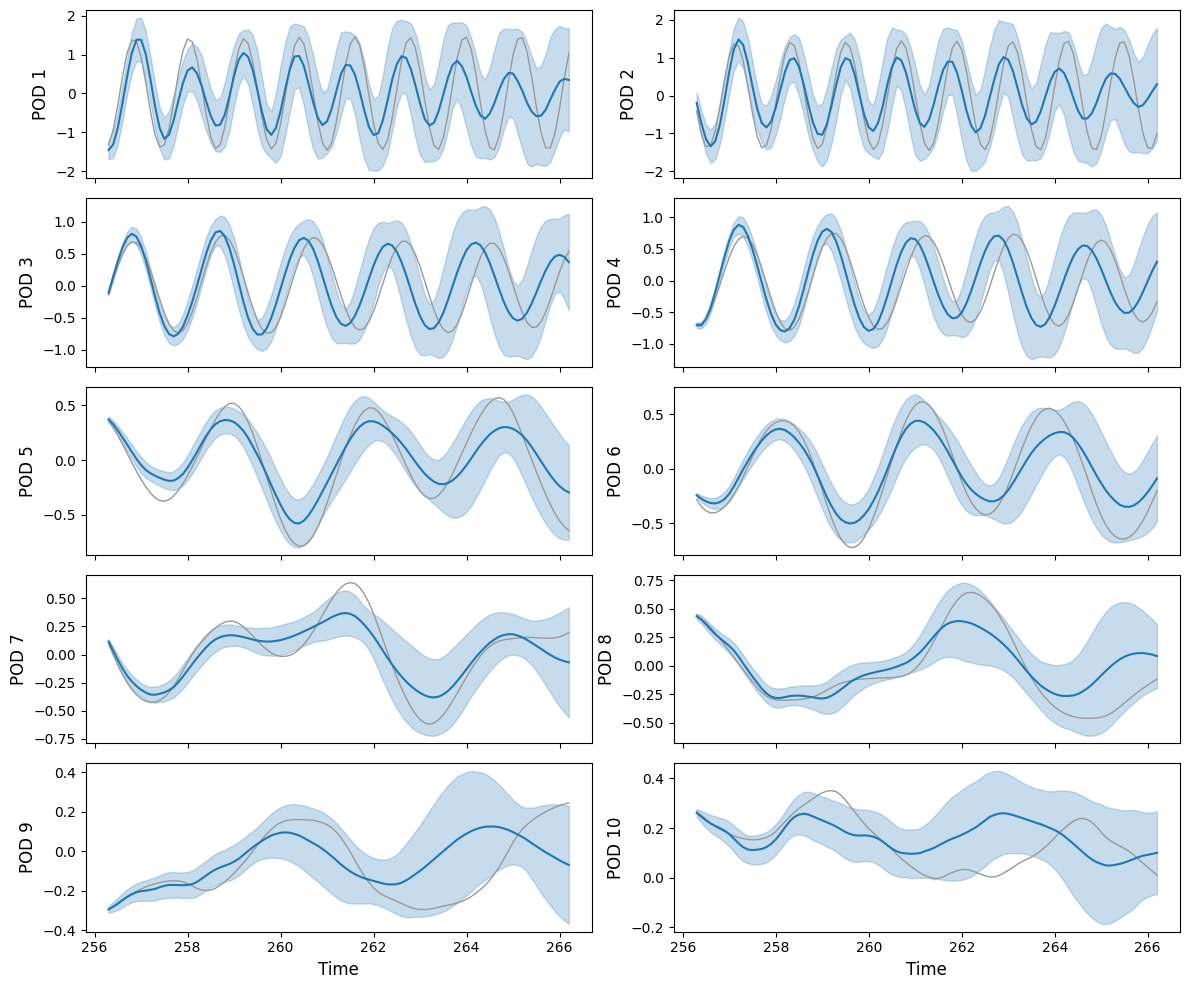

In [13]:
# Forecast from the true final training state, stored at the frame times of the test data
n_forecast = 128
n_fc_frames = int(round(t_window / dt_frame))
t_fc_start = t_train[-1]
xs_fc = vmap(partial(simulate_frames, x0=jnp.array(z_train[-1]), sde=prior, sde_params=params["sde_params"], dt_frame=dt_frame, n_frames=n_fc_frames, steps_per_frame=int(round(dt_frame / dt_sim))))(jr.split(jr.PRNGKey(99), n_forecast)) # (n_forecast, n_fc_frames, K)
xs_fc = np.array(xs_fc)
t_fc, z_test_fc = t_test[:n_fc_frames], z_test[:n_fc_frames] # the test frames of the forecast window
assert np.allclose(t_fc_start + dt_frame * np.arange(1, n_fc_frames + 1), t_fc) # the stored states fall on the times of the test frames

mean_fc, std_fc = xs_fc.mean(axis=0), xs_fc.std(axis=0)
fig, axs = plot_pod_modes(t_fc + t_offset, z_test_fc, t_fc + t_offset, mean=mean_fc, band=(mean_fc - 2 * std_fc, mean_fc + 2 * std_fc), fontsize=fontsize)
plt.show()

We see that the trajectories simulated from the learned prior closely track the true POD coefficients for about 5 time units into the forecasting window. 
Between 5 and 10 time units, the trajectories drift off phase from the true coefficients.

Next, we visualize the mean velocity field $4$ time units into the forecasting window against the true velocity field (reduced to the $K = 38$ POD coefficients), together with the standard deviation of the forecast velocity.

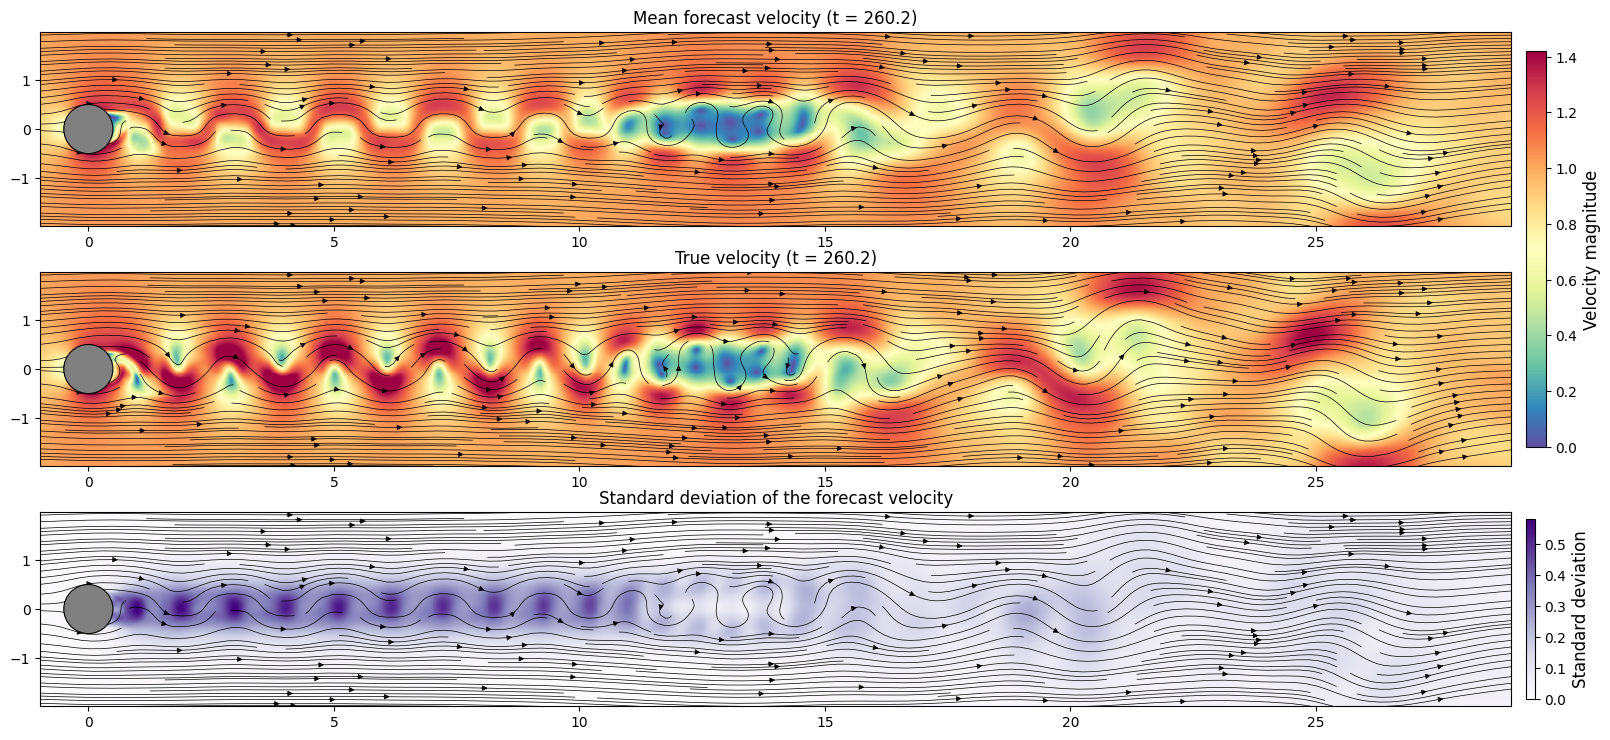

In [14]:
# Velocity fields 4 time units into the forecast
t_snapshot = t_fc_start + 4.0
idx = int(np.argmin(np.abs(t_fc - t_snapshot)))
u_fc, v_fc = decode_velocity(xs_fc[:, idx], pca_components, pca_mean, grid_shape, z_scale) # (n_forecast, n_y, n_x)
u_true, v_true = decode_velocity(z_test_fc[idx], pca_components, pca_mean, grid_shape, z_scale)
u_mean, v_mean = u_fc.mean(axis=0), v_fc.mean(axis=0)
std_vel = np.sqrt(u_fc.var(axis=0) + v_fc.var(axis=0))
vel_max = np.percentile(np.hypot(u_true, v_true), 99)

fig, axs = plt.subplots(3, 1, figsize=(16, 2.4 * 3), constrained_layout=True)
im_mean = plot_field(np.hypot(u_mean, v_mean), x_coord, y_coord, axs[0], u=u_mean, v=v_mean, vmin=0, vmax=vel_max, title=f"Mean forecast velocity (t = {t_fc[idx] + t_offset:.1f})", fontsize=fontsize)
plot_field(np.hypot(u_true, v_true), x_coord, y_coord, axs[1], u=u_true, v=v_true, vmin=0, vmax=vel_max, title=f"True velocity (t = {t_fc[idx] + t_offset:.1f})", fontsize=fontsize)
im_std = plot_field(std_vel, x_coord, y_coord, axs[2], u=u_mean, v=v_mean, cmap="Purples", vmin=0, title="Standard deviation of the forecast velocity", fontsize=fontsize)
add_colorbar(fig, im_mean, axs[:2], "Velocity magnitude", fontsize)
add_colorbar(fig, im_std, axs[2:], "Standard deviation", fontsize)
plt.show()

The forecasted mean velocity field resembles the true velocity field. The standard deviation in the forecast velocity field is largest in the wake of the cylinder.

We quantify the accuracy of the forecast by the squared error between each sample path and the true POD coefficients, summed over the coefficients, averaged over the sample paths, and summed over the frames of the $10$ time unit window. 

We report the error per POD coefficient and, since the POD basis is orthonormal, per velocity component of the grid.

Cumulative squared forecast error over the 10-unit window, per POD coefficient: 6.8745 (sample paths), 4.5838 (mean forecast)
Per velocity component of the grid: 3.1525 (sample paths), 2.1020 (mean forecast)


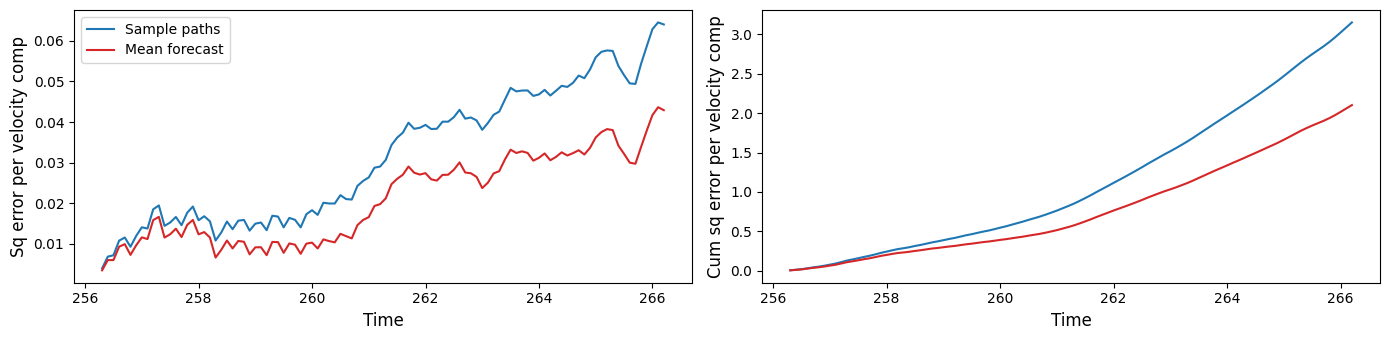

In [15]:
sq_err_t = np.mean(np.sum((xs_fc - z_test_fc[None]) ** 2, axis=2), axis=0) # (n_fc_frames), sample paths
sq_err_mean_t = np.sum((xs_fc.mean(axis=0) - z_test_fc) ** 2, axis=1) # (n_fc_frames), mean forecast
n_dims = pca_components.shape[-1] # velocity components on the grid
phys_scale = z_scale ** 2 / n_dims # squared error per POD coefficient summed over the coefficients -> per velocity component of the grid
t_fc_phys = t_fc + t_offset
print(f"Cumulative squared forecast error over the {t_window:.0f}-unit window, per POD coefficient: {sq_err_t.sum() / K:.4f} (sample paths), {sq_err_mean_t.sum() / K:.4f} (mean forecast)")
print(f"Per velocity component of the grid: {sq_err_t.sum() * phys_scale:.4f} (sample paths), {sq_err_mean_t.sum() * phys_scale:.4f} (mean forecast)")

fig, axs = plt.subplots(1, 2, figsize=(14, 3.5))
for ax, (curves, ylabel) in zip(axs, (((sq_err_t, sq_err_mean_t), "Sq error"), ((np.cumsum(sq_err_t), np.cumsum(sq_err_mean_t)), "Cum sq error"))):
    ax.plot(t_fc_phys, curves[0] * phys_scale, color="C0", label="Sample paths")
    ax.plot(t_fc_phys, curves[1] * phys_scale, color="C3", label="Mean forecast")
    ax.set_xlabel("Time", fontsize=fontsize)
    ax.set_ylabel(f"{ylabel} per velocity comp", fontsize=fontsize)
    ax.tick_params(labelsize=fontsize - 2)
axs[0].legend(fontsize=fontsize - 2)
fig.tight_layout()
plt.show()

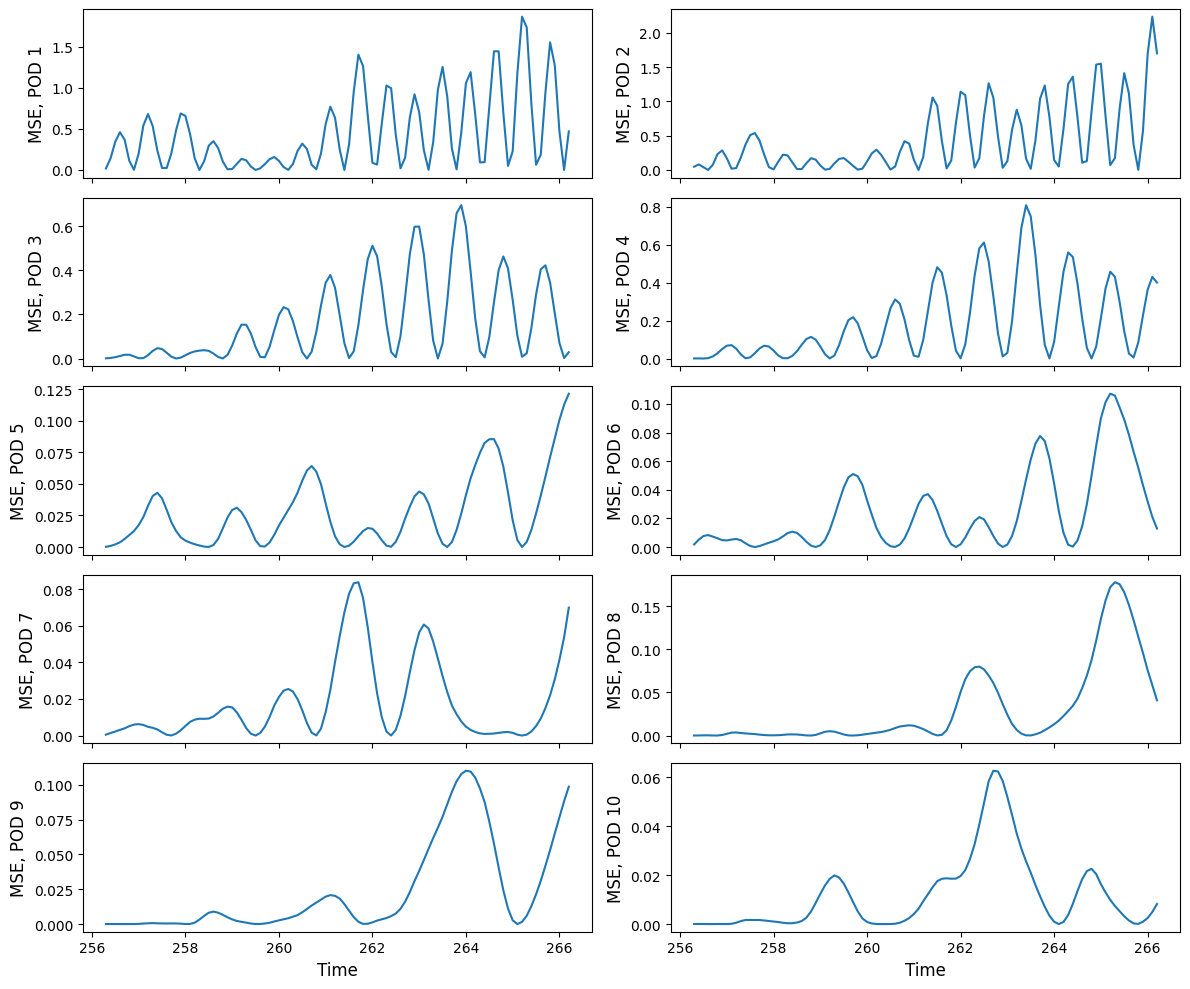

In [16]:
# Squared error of the mean forecast over time, per POD coefficient
fig, axs = plot_pod_modes(t_model=t_fc_phys, mean=(xs_fc.mean(axis=0) - z_test_fc) ** 2, ylabel="MSE, POD", fontsize=fontsize)
plt.show()

## Space-time correlation along the wake

Finally, we compute the two-point space-time correlation of the streamwise velocity fluctuations along the centerline of the wake from sample paths of the learned prior over the first $10$ time units as well as for the true velocity field.

In [ ]:
# Wake region: the grid points within y_band of the centerline between x_min and x_max, and the POD basis restricted to them
x_min, x_max, y_band = 1.0, 10.0, 0.1
component = 0 # 0 for the streamwise velocity u, 1 for the transverse velocity v
max_lag_x, max_lag_t = 2.0, 5.0
n_y, n_x = grid_shape
x_unique, y_unique = np.unique(x_coord), np.unique(y_coord)
rows, cols = np.where(np.abs(y_unique) <= y_band)[0], np.where((x_unique >= x_min) & (x_unique <= x_max))[0]
x_wake = x_unique[cols]
wake = (rows[:, None] * n_x + cols[None, :]).ravel() + component * n_y * n_x # flat indices of the wake points in the state vector [u, v]
pca_wake, pca_mean_wake = pca_components[:, wake], pca_mean[wake]

def wake_fluctuations(z):
    vel = ((np.asarray(z) * z_scale) @ pca_wake + pca_mean_wake).reshape(-1, len(rows), len(cols)).mean(axis=1) # (T, n_x)
    return vel - vel.mean(axis=0)

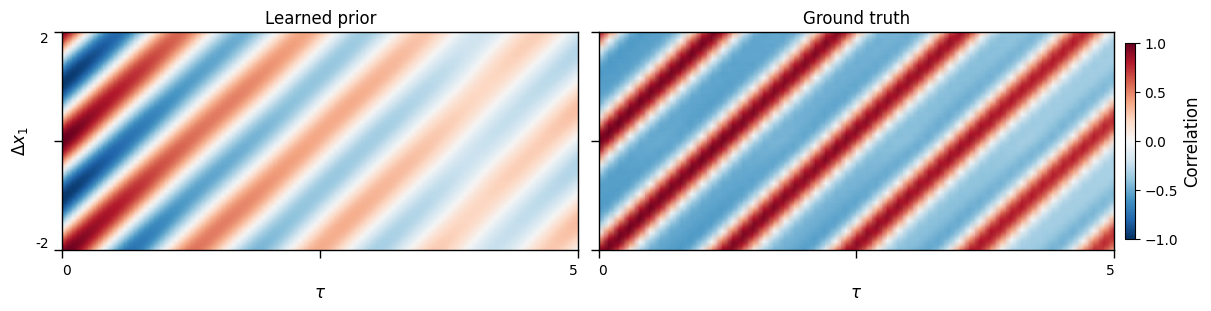

In [18]:
# Correlation of the learned prior, averaged over the sample paths, and of the true velocity field over all frames
dx = x_wake[1] - x_wake[0]
C_prior = np.mean([spacetime_correlation(wake_fluctuations(xs_prior[s]), dx, dt_prior, max_lag_x, max_lag_t)[0] for s in range(n_prior_samples)], axis=0)
_, lag_x, lag_t = spacetime_correlation(wake_fluctuations(xs_prior[0]), dx, dt_prior, max_lag_x, max_lag_t)
C_true, lag_x_true, lag_t_true = spacetime_correlation(wake_fluctuations(np.concatenate([z_train, z_test])), dx, dt_frame, max_lag_x, max_lag_t)

fig, axs = plt.subplots(1, 2, figsize=(12, 3), sharey=True, constrained_layout=True)
plot_spacetime_correlation(C_prior, lag_x, lag_t, axs[0], title="Learned prior", fontsize=fontsize)
im = plot_spacetime_correlation(C_true, lag_x_true, lag_t_true, axs[1], title="Ground truth", fontsize=fontsize)
axs[1].set_ylabel("")
add_colorbar(fig, im, axs, r"Correlation", fontsize)
plt.show()

The correlation of the learned prior reproduces the diagonal ridges of the true velocity field, which correspond to the vortices being advected downstream. 